# 04 - Tournament Simulation & Outcome Visualizations

Monte Carlo simulate the 48-team 2026 World Cup, then explore the results with a set of advanced outcome visualizations from `wcpredictor.visualization`.

**The tournament is already under way, so we condition on the matches that have actually been played.** The group stage and the completed knockout rounds are settled facts, not things to re-simulate: `load_tournament_state` reads them from the vendored 2026 fixtures, and `sim.run_conditioned` rolls dice only from the current bracket onward. A team that has already been eliminated therefore has a 0% chance of winning -- re-simulating the whole event from scratch (`sim.run`) would instead hand already-out sides like Germany or the Netherlands a championship probability they can no longer have.

In [1]:
import matplotlib.pyplot as plt
import pandas as pd

from wcpredictor.config import default_config

config = default_config()
plt.rcParams["figure.figsize"] = (9, 4.5)

from wcpredictor.data import (load_matches, load_groups,
                            load_tournament_state)
from wcpredictor.data.preprocess import build_training_matches
from wcpredictor.models import PoissonModel
from wcpredictor.simulation import TournamentSimulator
from wcpredictor import visualization as viz
import numpy as np

In [2]:
tr = build_training_matches(load_matches(config), config)
poisson = PoissonModel(config).fit(tr)
groups = load_groups(config)
sim = TournamentSimulator(poisson, groups, config)

# Condition on what has actually happened so far. `state` records
# how far each team has already gone and the current (frontier)
# knockout round; only that round onward is simulated.
state = load_tournament_state(config)
alive = ', '.join(state.alive)
print(f'Current round: {state.frontier_stage.replace("_", " ")}')
print(f'Still alive ({len(state.alive)}): {alive}')
report = sim.run_conditioned(
    state, n_simulations=config.simulation.n_simulations)
report.table.head(12)

Current round: quarterfinal
Still alive (8): France, Morocco, Spain, Belgium, Norway, England, Argentina, Switzerland


,team,group,p_advance,p_round_of_16,p_quarterfinal,p_semifinal,p_final,p_winner,p_group_1st,p_group_2nd,p_group_3rd,p_group_4th
0,France,I,1.0,1.0,1.0,0.6364,0.3666,0.2419,1.0,0.0,0.0,0.0
1,Spain,H,1.0,1.0,1.0,0.6022,0.3092,0.1949,1.0,0.0,0.0,0.0
2,England,L,1.0,1.0,1.0,0.6367,0.3625,0.1606,1.0,0.0,0.0,0.0
3,Argentina,J,1.0,1.0,1.0,0.6848,0.3696,0.1592,1.0,0.0,0.0,0.0
4,Belgium,G,1.0,1.0,1.0,0.3978,0.1651,0.0850,1.0,0.0,0.0,0.0
5,Morocco,C,1.0,1.0,1.0,0.3636,0.1591,0.0819,0.0,1.0,0.0,0.0
6,Norway,I,1.0,1.0,1.0,0.3633,0.1611,0.0477,0.0,1.0,0.0,0.0
7,Switzerland,B,1.0,1.0,1.0,0.3152,0.1068,0.0288,1.0,0.0,0.0,0.0
8,Mexico,A,1.0,1.0,0.0,0.0000,0.0000,0.0000,1.0,0.0,0.0,0.0
9,South Africa,A,1.0,0.0,0.0,0.0000,0.0000,0.0000,0.0,1.0,0.0,0.0


### Monte Carlo uncertainty

Each probability comes from a finite number of simulated tournaments, so it carries sampling error: s.e. = sqrt(p(1-p)/n).

In [3]:
report.standard_errors().head(12)

,team,group,se_advance,se_round_of_16,se_quarterfinal,se_semifinal,se_final,se_winner,se_group_1st,se_group_2nd,se_group_3rd,se_group_4th
0,France,I,0.0,0.0,0.0,0.004810,0.004819,0.004282,0.0,0.0,0.0,0.0
1,Spain,H,0.0,0.0,0.0,0.004894,0.004622,0.003961,0.0,0.0,0.0,0.0
2,England,L,0.0,0.0,0.0,0.004810,0.004807,0.003672,0.0,0.0,0.0,0.0
3,Argentina,J,0.0,0.0,0.0,0.004646,0.004827,0.003659,0.0,0.0,0.0,0.0
4,Belgium,G,0.0,0.0,0.0,0.004894,0.003713,0.002789,0.0,0.0,0.0,0.0
5,Morocco,C,0.0,0.0,0.0,0.004810,0.003658,0.002742,0.0,0.0,0.0,0.0
6,Norway,I,0.0,0.0,0.0,0.004810,0.003676,0.002131,0.0,0.0,0.0,0.0
7,Switzerland,B,0.0,0.0,0.0,0.004646,0.003089,0.001672,0.0,0.0,0.0,0.0
8,Mexico,A,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0
9,South Africa,A,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0


## The title race

A lollipop chart of each contender's probability of lifting the trophy. The horizontal error bars are 95% confidence intervals (±1.96 s.e.) reflecting Monte Carlo sampling uncertainty, not additional model uncertainty.

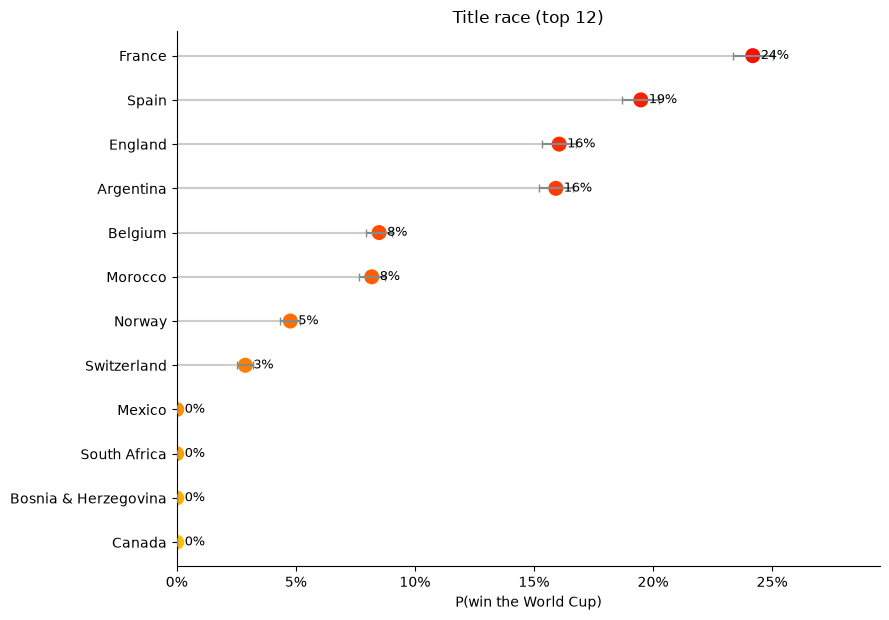

In [4]:
viz.plot_title_race(report, top_n=12)
plt.tight_layout(); plt.show()

## Full finish distribution

The headline outcome chart: every bar spans 0-100% and is split into the *mutually exclusive* ways a team's tournament can end, from a group-stage exit (left) to champion (right, gold). This shows a team's entire range of plausible results at once.

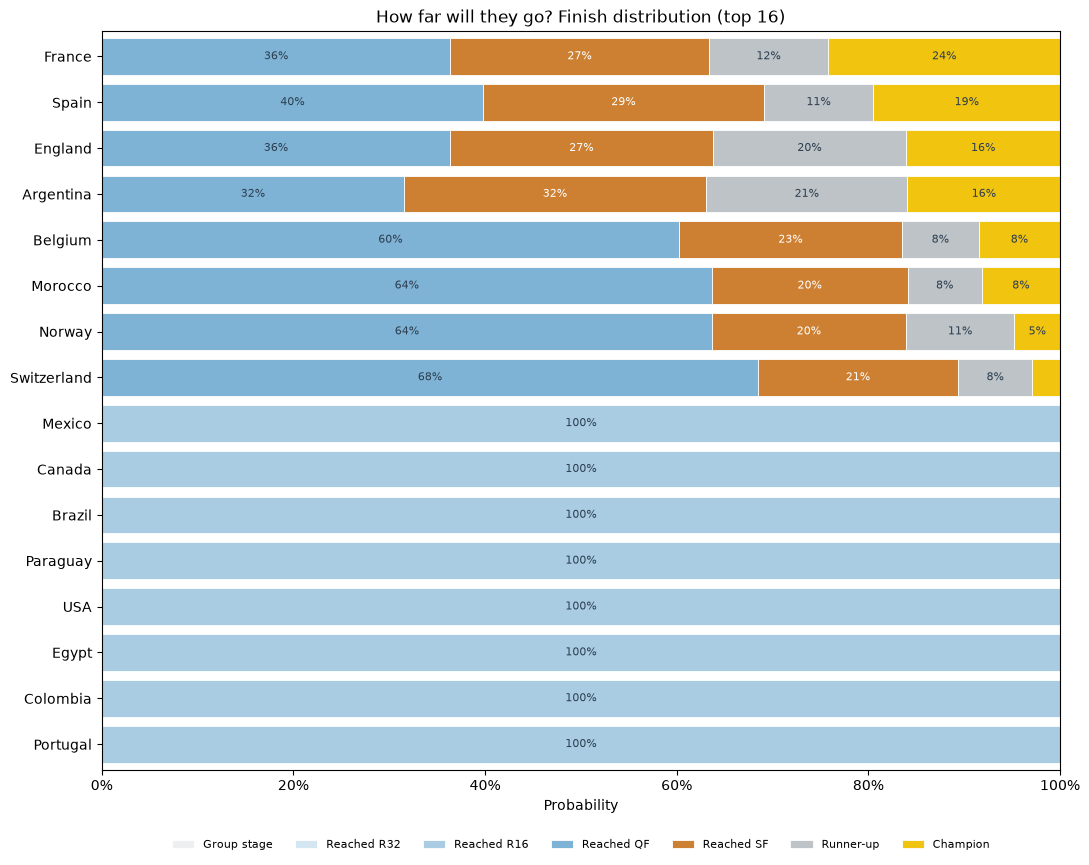

In [5]:
viz.plot_outcome_distribution(report, top_n=16)
plt.tight_layout(); plt.show()

## Reaching each stage (heatmap)

Cumulative probability of reaching each round.

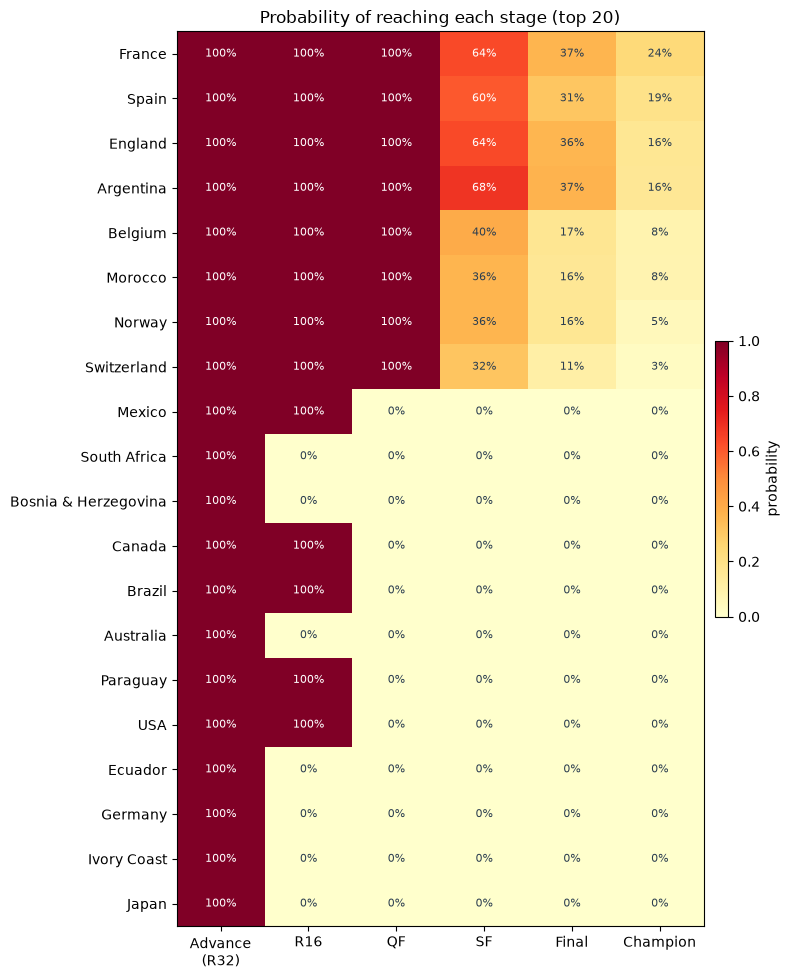

In [6]:
viz.plot_stage_heatmap(report, top_n=20)
plt.tight_layout(); plt.show()

## Group-stage outcomes

Probability of each team finishing 1st / 2nd / 3rd / 4th in their group (only the top two are guaranteed to advance; the best eight third-placed teams also progress).

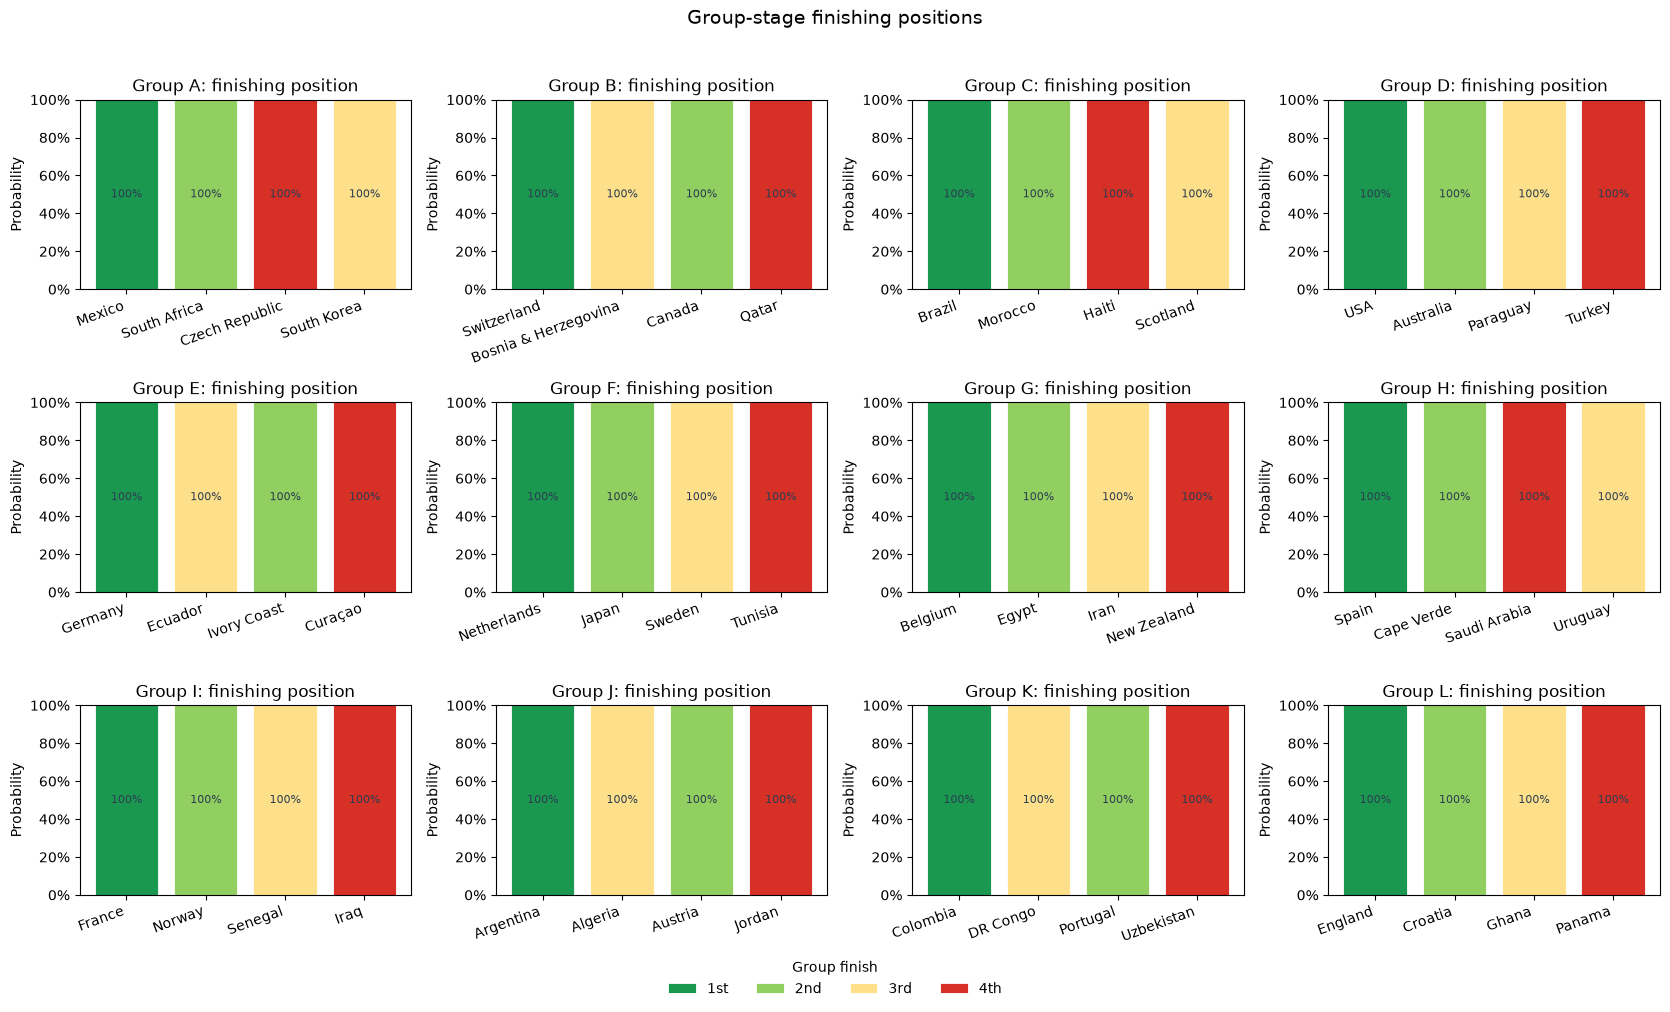

In [7]:
viz.plot_group_grid(report)
plt.show()

## Zoom into a single group

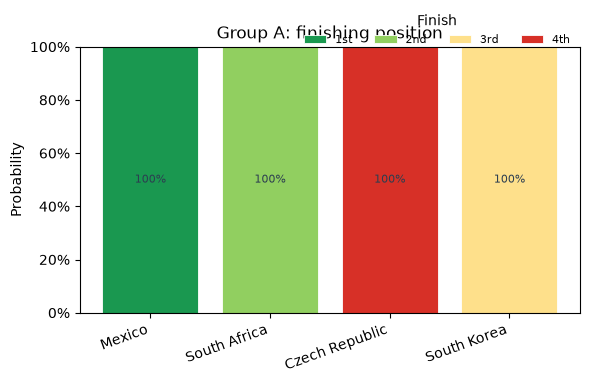

In [8]:
first_group = sorted(report.table['group'].unique())[0]
viz.plot_group_outcomes(report, first_group)
plt.tight_layout(); plt.show()

## Group difficulty

Strength-of-schedule view: mean Elo rating per group (hardest first), with individual team ratings overlaid so a strong outlier in an otherwise weak group is still visible.

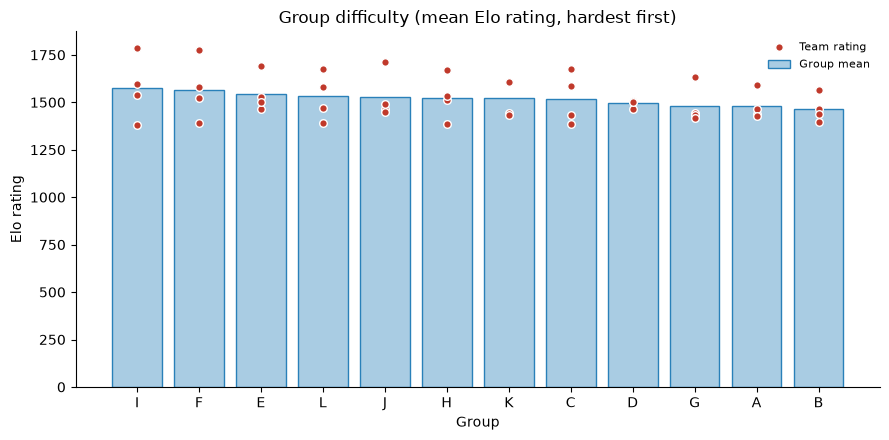

In [9]:
from wcpredictor.models import EloModel
from wcpredictor.visualization import plot_group_difficulty
elo = EloModel(config).fit(tr)
plot_group_difficulty(groups, elo)
plt.tight_layout(); plt.show()

## One simulated tournament (example bracket)

A single random realization of the *remaining* event, rolled forward from the current bracket. The finalists and semifinalists are therefore always drawn from the teams still alive.

In [10]:
rng = np.random.default_rng(7)
result = sim.simulate_once_conditioned(state, rng)
print('Champion:    ', result['champion'])
print('Finalists:   ', sorted(result['reached']['final']))
print('Semifinalists:', sorted(result['reached']['semifinal']))

Champion:     Spain
Finalists:    ['England', 'Spain']
Semifinalists: ['Argentina', 'England', 'Morocco', 'Spain']


## Most likely finish per team

The single most probable outcome for each of the favourites.

In [11]:
from wcpredictor.simulation.tournament import EXACT_OUTCOMES
label_map = dict(EXACT_OUTCOMES)
keys = [k for k, _ in EXACT_OUTCOMES]
dist = report.outcome_distribution()
dist['most_likely'] = dist[keys].idxmax(axis=1).map(label_map)
dist['p_most_likely'] = dist[keys].max(axis=1)
dist.sort_values('champion', ascending=False)[['team', 'group', 'most_likely', 'p_most_likely', 'champion']].head(12)

,team,group,most_likely,p_most_likely,champion
0,France,I,Reached QF,0.3636,0.2419
1,Spain,H,Reached QF,0.3978,0.1949
2,England,L,Reached QF,0.3633,0.1606
3,Argentina,J,Reached QF,0.3152,0.1592
4,Belgium,G,Reached QF,0.6022,0.0850
5,Morocco,C,Reached QF,0.6364,0.0819
6,Norway,I,Reached QF,0.6367,0.0477
7,Switzerland,B,Reached QF,0.6848,0.0288
8,Mexico,A,Reached R16,1.0000,0.0000
9,South Africa,A,Reached R32,1.0000,0.0000
